# Modelos lineales: Regresión Lineal, Lasso y Ridge — notebook auxiliar
**Aprendizaje de Máquina - CEIA - FIUBA**

*Notebook auxiliar (no forma parte del flujo de clase).*

En el caso práctico de regresión (`3 - SVM (Regresion).ipynb`) entrenamos un SVR. Esta notebook desarrolla la familia de **modelos lineales** sobre el mismo dataset, para tener contra qué comparar al SVR:

1. **Regresión Lineal ordinaria (OLS)** — el modelo lineal más básico.
2. **Lasso** — regularización L1, que además **selecciona features** poniendo coeficientes en cero. Útil porque el EDA detectó **multicolinealidad severa**.
3. **Ridge** — regularización L2, que encoge los coeficientes sin eliminarlos.

Usamos **el mismo dataset, preprocesamiento y split** que el resto de las notebooks (`test_size=0.3`, `random_state=42`), de modo que las métricas sean directamente comparables. Los resultados se referencian en la comparativa final de `3 - SVM (Regresion).ipynb`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set()

## Datos y preprocesamiento

Réplica del preprocesamiento justificado en el EDA (`EDA - Hitters.ipynb`): descartamos los salarios faltantes, modelamos `log(Salary)`, generamos las variables dummy de las categóricas y escalamos dentro de un `Pipeline`.

In [2]:
df_hitters = pd.read_csv("datasets/Hitters.csv")
df_hitters = df_hitters.dropna(subset="Salary").copy()
df_hitters["Salary_log"] = np.log(df_hitters["Salary"])

dummies = pd.get_dummies(df_hitters, columns=["League", "Division", "NewLeague"],
                         drop_first=True)
X_cols = ['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat',
          'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists',
          'Errors', 'League_N', 'Division_W', 'NewLeague_N']
X = dummies[X_cols]
y = dummies["Salary_log"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
    random_state=42)

print("Train:", X_train.shape[0], "| Test:", X_test.shape[0], "| Features:", X_train.shape[1])

Train: 184 | Test: 79 | Features: 19


---
# 1. Regresión lineal ordinaria (OLS)

Entrenamos una regresión lineal simple dentro de un `Pipeline` con `StandardScaler`. Como métrica principal usamos el **MAE** (igual que en el caso práctico).

In [3]:
ols = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
ols.fit(X_train, y_train)

y_pred_ols = ols.predict(X_test)

print("Regresión Lineal (OLS)")
print(f"MAE de testeo fue:  {mean_absolute_error(y_test, y_pred_ols):.4f}")
print(f"RMSE de testeo fue: {root_mean_squared_error(y_test, y_pred_ols):.4f}")
print(f"MAPE de testeo fue: {mean_absolute_percentage_error(y_test, y_pred_ols):.4f}")
print(f"R2 de testeo fue:   {r2_score(y_test, y_pred_ols):.4f}")

Regresión Lineal (OLS)
MAE de testeo fue:  0.5154
RMSE de testeo fue: 0.6779
MAPE de testeo fue: 0.0907
R2 de testeo fue:   0.4103


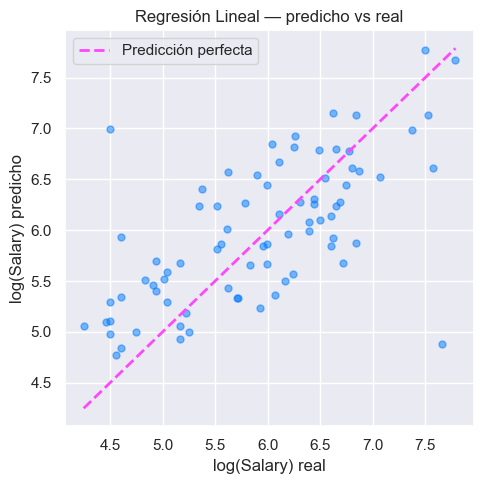

In [4]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test, y_pred_ols, color="#007aff", alpha=0.5, s=25)
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, "--", color="#ff48fd", linewidth=2, label="Predicción perfecta")
ax.set_xlabel("log(Salary) real")
ax.set_ylabel("log(Salary) predicho")
ax.set_title("Regresión Lineal — predicho vs real")
ax.legend()
plt.tight_layout()
plt.show()

### Coeficientes

Con los datos estandarizados, cada coeficiente indica cuánto cambia `log(Salary)` ante un aumento de una desviación estándar de la feature.

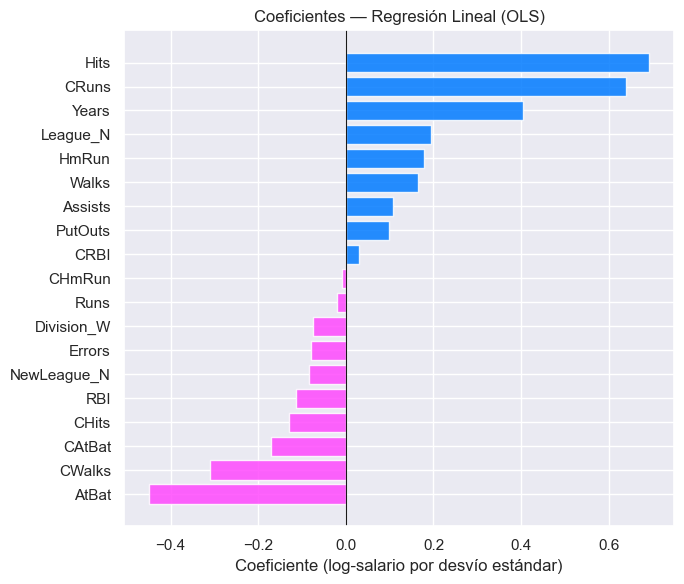

In [5]:
coefs_ols = pd.Series(ols.named_steps['model'].coef_, index=X_cols).sort_values()

fig, ax = plt.subplots(figsize=(7, 6))
colores = ["#007aff" if c > 0 else "#ff48fd" for c in coefs_ols]
ax.barh(coefs_ols.index, coefs_ols.values, color=colores, alpha=0.85)
ax.axvline(0, color="k", linewidth=0.8)
ax.set_xlabel("Coeficiente (log-salario por desvío estándar)")
ax.set_title("Coeficientes — Regresión Lineal (OLS)")
plt.tight_layout()
plt.show()

Los coeficientes de OLS son difíciles de interpretar: por la **multicolinealidad** entre las variables de carrera (que el EDA mostró con correlaciones >0.9), el modelo reparte el peso de forma inestable e incluso asigna **signos negativos** a features que aisladamente correlacionan positivo con el salario (p. ej. `CAtBat`, `CWalks`). Es un síntoma clásico de multicolinealidad: OLS usa las 19 features, muchas redundantes entre sí.

---
# 2. Lasso: regularización L1 y selección de features

Como vimos varias variables colineales en el EDA, probamos una regresión **Lasso**. Su penalización L1 tiende a **poner en cero** los coeficientes de las features redundantes, dejando un subconjunto más chico e interpretable. Buscamos el mejor `alpha` por validación cruzada.

In [6]:
grid_lasso = GridSearchCV(
    Pipeline([('scaler', StandardScaler()), ('model', Lasso(max_iter=10000))]),
    {"model__alpha": np.logspace(-3, 0, 50)},
    cv=5,
    scoring='neg_mean_absolute_error')
grid_lasso.fit(X_train, y_train)

lasso = grid_lasso.best_estimator_
y_pred_lasso = lasso.predict(X_test)

coefs_lasso = pd.Series(lasso.named_steps['model'].coef_, index=X_cols)
conservadas = coefs_lasso[coefs_lasso != 0].index.tolist()
eliminadas = coefs_lasso[coefs_lasso == 0].index.tolist()

print(f"Mejor alpha: {grid_lasso.best_params_['model__alpha']:.4f}")
print(f"MAE de testeo (Lasso): {mean_absolute_error(y_test, y_pred_lasso):.4f}")
print(f"\nLasso puso en CERO {len(eliminadas)} de {len(X_cols)} features:")
print(" ", eliminadas)
print(f"\nConserva {len(conservadas)} features:")
print(" ", conservadas)

Mejor alpha: 0.0193
MAE de testeo (Lasso): 0.5156

Lasso puso en CERO 8 de 19 features:
  ['AtBat', 'RBI', 'CAtBat', 'CHmRun', 'CRBI', 'CWalks', 'Assists', 'NewLeague_N']

Conserva 11 features:
  ['Hits', 'HmRun', 'Runs', 'Walks', 'Years', 'CHits', 'CRuns', 'PutOuts', 'Errors', 'League_N', 'Division_W']


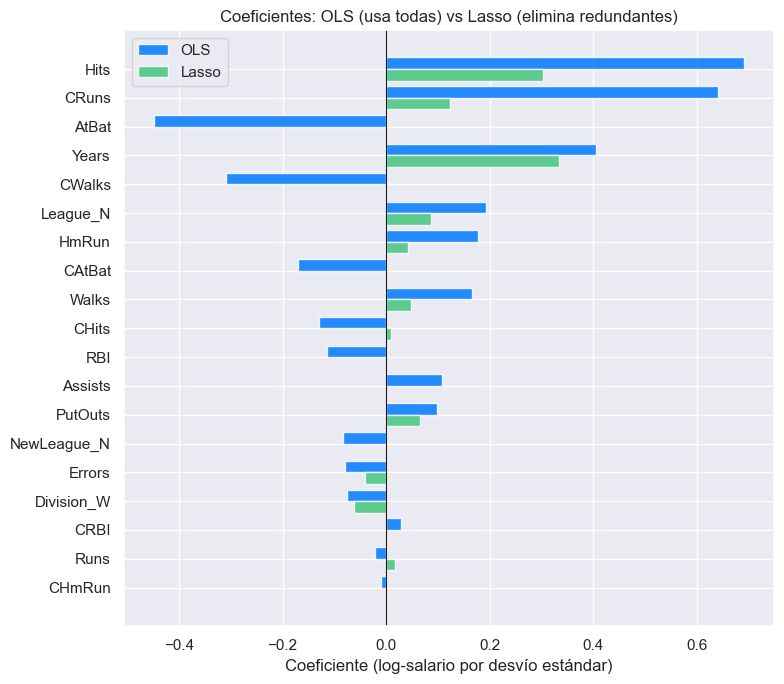

In [7]:
# Comparación de coeficientes OLS vs Lasso
comp = pd.DataFrame({"OLS": coefs_ols, "Lasso": coefs_lasso}).loc[X_cols]
comp = comp.reindex(comp["OLS"].abs().sort_values().index)

y_pos = np.arange(len(comp))
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(y_pos + 0.2, comp["OLS"], height=0.4, color="#007aff", alpha=0.85, label="OLS")
ax.barh(y_pos - 0.2, comp["Lasso"], height=0.4, color="#44c57f", alpha=0.85, label="Lasso")
ax.set_yticks(y_pos)
ax.set_yticklabels(comp.index)
ax.axvline(0, color="k", linewidth=0.8)
ax.set_xlabel("Coeficiente (log-salario por desvío estándar)")
ax.set_title("Coeficientes: OLS (usa todas) vs Lasso (elimina redundantes)")
ax.legend()
plt.tight_layout()
plt.show()

Lasso elimina varias variables de carrera redundantes (como `CAtBat`, `CHmRun`, `CRBI`, `CWalks`), quedándose con un modelo más parsimonioso —**alrededor de la mitad de las features**— sin perder prácticamente nada de performance. Es la respuesta directa a la multicolinealidad que detectamos en el EDA.

---
# 3. Ridge: regularización L2

La regresión **Ridge** también regulariza, pero con penalización L2: **encoge** los coeficientes hacia cero sin llegar a eliminarlos. Es el otro modelo lineal clásico contra el cual comparar. Buscamos el mejor `alpha` por validación cruzada.

In [8]:
grid_ridge = GridSearchCV(
    Pipeline([('scaler', StandardScaler()), ('model', Ridge())]),
    {"model__alpha": np.linspace(0.01, 20, 500)},
    cv=5,
    scoring='neg_mean_absolute_error')
grid_ridge.fit(X_train, y_train)

ridge = grid_ridge.best_estimator_
y_pred_ridge = ridge.predict(X_test)

print(f"Mejor alpha: {grid_ridge.best_params_['model__alpha']:.4f}")
print("Regresión Ridge")
print(f"MAE de testeo fue:  {mean_absolute_error(y_test, y_pred_ridge):.4f}")
print(f"RMSE de testeo fue: {root_mean_squared_error(y_test, y_pred_ridge):.4f}")
print(f"R2 de testeo fue:   {r2_score(y_test, y_pred_ridge):.4f}")

Mejor alpha: 13.6705
Regresión Ridge
MAE de testeo fue:  0.5118
RMSE de testeo fue: 0.6626
R2 de testeo fue:   0.4366


---
## Comparativa de los modelos lineales

Comparamos los tres modelos lineales contra el **baseline por tramos de años** definido en el EDA (`EDA - Hitters.ipynb`).

In [9]:
# Baseline: promedio de log(Salary) por tramo de años (ver EDA - Hitters)
bins = [0, 2, 4, 6, 9, 13, np.inf]
tramo_train = pd.cut(X_train["Years"], bins=bins)
tramo_test = pd.cut(X_test["Years"], bins=bins)
prom_por_tramo = y_train.groupby(tramo_train, observed=False).mean()
y_pred_base = tramo_test.map(prom_por_tramo).astype(float).values

modelos = ["Baseline (tramos de años)", "Regresión Lineal", "Lasso", "Ridge"]
preds = [y_pred_base, y_pred_ols, y_pred_lasso, y_pred_ridge]

df_cmp = pd.DataFrame({
    "MAE": [mean_absolute_error(y_test, p) for p in preds],
    "RMSE": [root_mean_squared_error(y_test, p) for p in preds],
    "R2": [r2_score(y_test, p) for p in preds],
}, index=pd.Index(modelos))

df_cmp.round(4)

,MAE,RMSE,R2
Baseline (tramos de años),0.5068,0.7027,0.3665
Regresión Lineal,0.5154,0.6779,0.4103
Lasso,0.5156,0.6724,0.4199
Ridge,0.5118,0.6626,0.4366


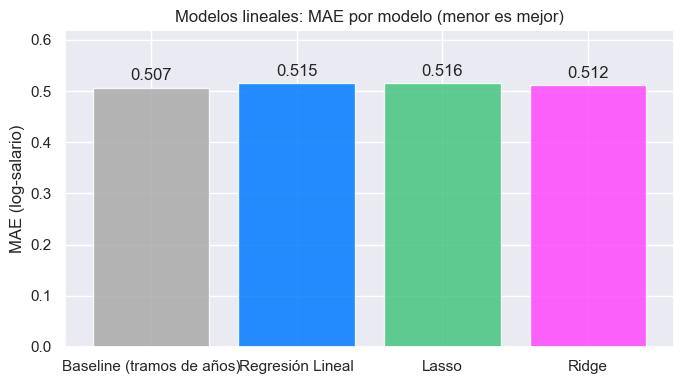

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
colores = ["#aaaaaa", "#007aff", "#44c57f", "#ff48fd"]
bars = ax.bar(df_cmp.index, df_cmp["MAE"], color=colores, alpha=0.85)
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set_ylabel("MAE (log-salario)")
ax.set_title("Modelos lineales: MAE por modelo (menor es mejor)")
ax.set_ylim(0, df_cmp["MAE"].max() * 1.2)
plt.tight_layout()
plt.show()

---
## Resultado para referenciar en clase 3

Los tres modelos lineales quedan muy parejos (**MAE ≈ 0.51–0.52**) y apenas mejoran sobre el baseline por tramos de años. La regularización aporta lo suyo:

- **Lasso** logra un modelo **más simple** (elimina ~la mitad de las features colineales) sin perder performance.
- **Ridge** obtiene el mejor MAE de los lineales, encogiendo los coeficientes.

Ninguno, sin embargo, despega demasiado del baseline: la relación entre las estadísticas y el salario no es puramente lineal.